<div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 40px; margin-top: 0;">
    <div style="flex: 0 0 auto; margin-left: 0; margin-bottom: 0; margin-top: 0;">
        <img src="./pics/UCSD Logo.png" alt="UCSD Logo" style="width: 179px; margin-bottom: 0px; margin-top: 20px;">
    </div>
    <div style="flex: 0 0 auto; margin-left: auto; margin-bottom: 0; margin-top: 20px;">
        <img src="./pics/LANL-logo.png" alt="LANL Logo" style="width: 200px; margin-bottom: 0px;">
    </div>
    <div style="flex: 0 0 auto; margin-left: auto; margin-bottom: 0; margin-top: 20px;">
        <img src="./pics/prowess.png" alt="Prowess Logo" style="width: 200px; margin-bottom: 0px;">
    </div>
    <div style="flex: 0 0 auto; margin-left: auto; margin-bottom: 0; margin-top: 20px;">
        <img src="./pics/wildfire.png" alt="WildFire Logo" width="100"/>
    </div>
</div>

<h1 style="text-align: center; font-size: 48px; margin-top: 0;">Fire-Ready Forests Data Challenge</h1>

# Sprint 1 - Tasks 1-4

**Team Name: HeatMappers**

**Members:**
- Ansh Bhatnagar
- Jiahe Qin
- Jeronimo Adames-Baena
- Ishayu Ghosh

Use this notebook to report your solutions for tasks 1-4 of Sprint 1. Add code and markdown cells as needed to report your solutions.

### Task 1

The FIA database and the field data collection are very similar in terms of what is being recorded, but there are differences in the population they each describe. 

Using the FIA database and the field data notebooks as a guide, filter the field data for Independence Lake (site_name = ‘ind’) and the FIA database for the corresponding ecosystem (filter on ECOSUBCD = ‘M261Ej’). Explore the datasets and take a look at 2 equivalent columns (for example, the species, diameter, heights, etc. Don't forget to take into account that the units may be different).

Describe how the populations of these two datasets compare (i.e. distributions, averages, is one dataset more detailed than the other, etc.). Provide at least 2 figures in your response.


In [2]:
import folium
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [3]:
DATA_PATH = Path("data")
df_plots = pd.read_csv("data/01_plot_identification.csv")
df_trees = pd.read_csv("data/03_tree.csv")
cols = ["site_name","site_name_label"]
df_trees = df_trees.merge(df_plots[["inventory_id"]+cols], on="inventory_id", how="left")
df_trees = df_trees[df_trees["site_name"]=="ind"]
fia_ca_plot_table = pd.read_csv(DATA_PATH / 'CA_PLOT.csv', low_memory=False)
fia_ca_plot_table = fia_ca_plot_table[fia_ca_plot_table['ECOSUBCD'] == "M261Ej"]
fia_ca_tree_table = pd.read_csv(DATA_PATH / 'CA_TREE.csv', low_memory=False)
fia_ref_species_table = pd.read_csv(DATA_PATH / 'REF_SPECIES.csv')
fia_ca_plot_table = fia_ca_plot_table[fia_ca_plot_table['ECOSUBCD'] == "M261Ej"]
fia_data = pd.merge(fia_ca_tree_table, fia_ca_plot_table, left_on='PLT_CN', right_on='CN')

### Height vs diameter (fia)

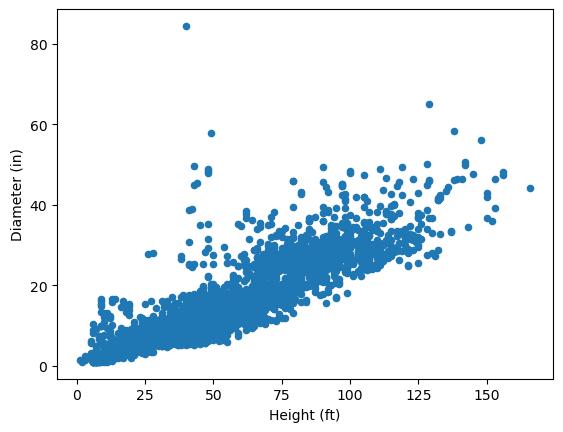

In [4]:
fig, ax = plt.subplots()
fia_data.plot.scatter(x="HT", y="DIA", ax=ax)
ax.set_xlabel("Height (ft)")
ax.set_ylabel("Diameter (in)")
plt.show()

### Height vs diameter (field)
##### The height in this dataset is in metres and the diameter in cm. So we need to convert to feet and inches to match above dataset

In [5]:
df_trees['height_feet'] = df_trees["tree_ht"] * 3.28084
df_trees['diameter_inches'] = df_trees["tree_dbh"] * 0.393701

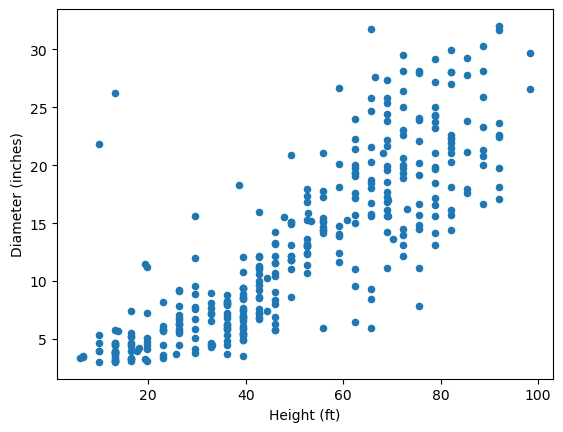

In [6]:
fig, ax = plt.subplots()
df_trees.plot.scatter(x="height_feet", y="diameter_inches", ax=ax)
ax.set_xlabel("Height (ft)")
ax.set_ylabel("Diameter (inches)")
plt.show()

### deal with missing values
###### Will remove because there are already many more observations in fia

In [7]:
print(np.count_nonzero(df_trees["height_feet"].isna()))
print(np.count_nonzero(df_trees["diameter_inches"].isna()))
print(np.count_nonzero(fia_data["HT"].isna()))
print(np.count_nonzero(fia_data["DIA"].isna()))
fia_data = fia_data.dropna(subset=['HT', 'DIA'])

0
0
364
364


In [8]:
print(np.count_nonzero(fia_data["HT"].isna()))
print(np.count_nonzero(fia_data["DIA"].isna()))

0
0


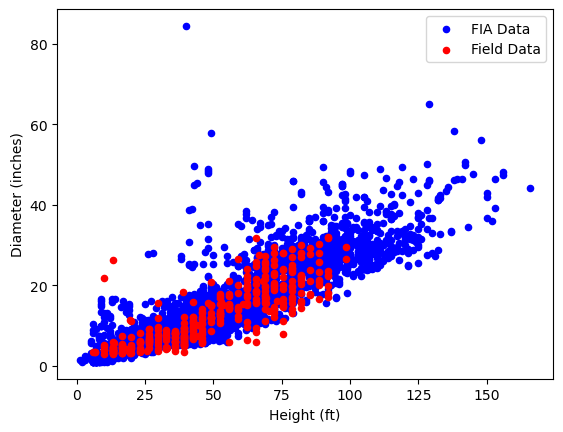

In [9]:
fig, ax = plt.subplots()
fia_data.plot.scatter(x="HT", y="DIA", color='blue', label='FIA Data', ax=ax)
df_trees.plot.scatter(x="height_feet", y="diameter_inches", color='red', label='Field Data', ax=ax)
ax.set_xlabel("Height (ft)")
ax.set_ylabel("Diameter (inches)")
plt.legend()
plt.show()

In [10]:
df_trees.get(["diameter_inches","height_feet"]).describe()

,diameter_inches,height_feet
count,358.000000,358.000000
mean,13.012699,50.082298
std,7.534743,23.280812
min,3.031498,5.905512
25%,6.299216,32.808400
50%,11.830715,49.212600
75%,18.563002,68.897640
max,32.007891,98.425200


In [11]:
fia_data.get(["DIA","HT"]).describe()

,DIA,HT
count,3754.000000,3754.000000
mean,14.058737,49.917421
std,9.870771,29.399471
min,1.000000,1.000000
25%,6.900000,27.000000
50%,10.700000,43.000000
75%,19.300000,69.000000
max,84.400000,166.000000


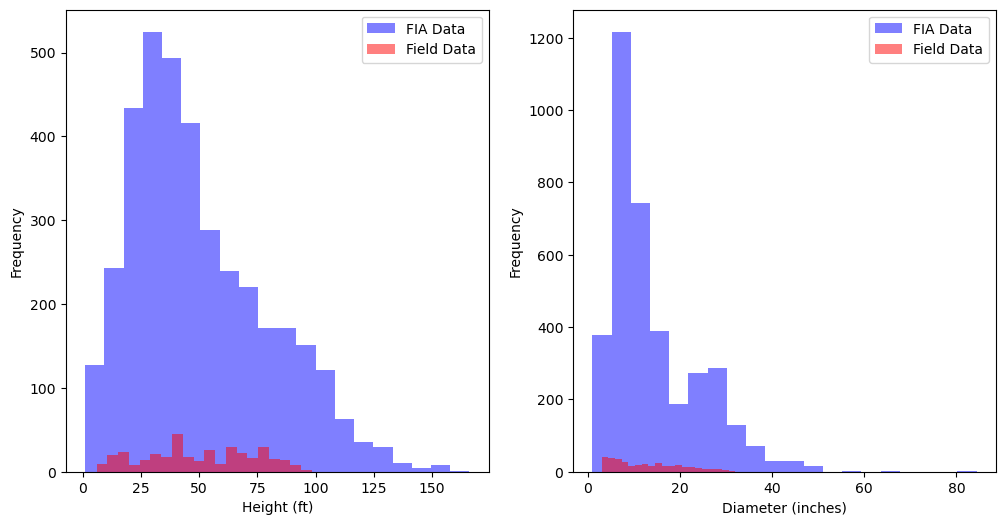

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.hist(fia_data['HT'], bins=20, alpha=0.5, label='FIA Data', color='blue')
ax1.hist(df_trees['height_feet'], bins=20, alpha=0.5, label='Field Data', color='red')
ax1.set_xlabel('Height (ft)')
ax1.set_ylabel('Frequency')
ax1.legend()

ax2.hist(fia_data['DIA'], bins=20, alpha=0.5, label='FIA Data', color='blue')
ax2.hist(df_trees['diameter_inches'], bins=20, alpha=0.5, label='Field Data', color='red')
ax2.set_xlabel('Diameter (inches)')
ax2.set_ylabel('Frequency')
ax2.legend()

plt.show()

R-squared: 0.7992898744537025


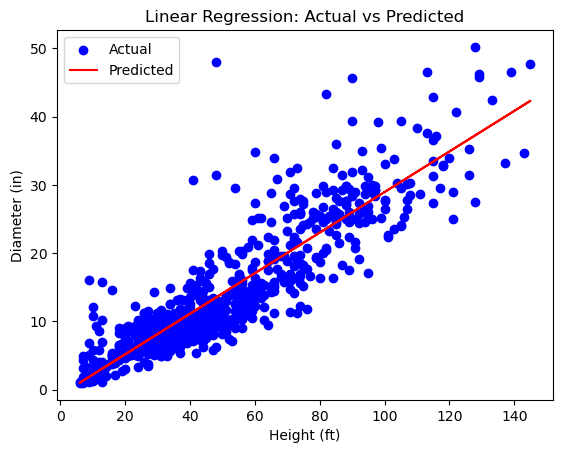

FIA Regression Coefficients: Slope = 0.29713422770940634, Intercept = -0.768527723471605


In [13]:
X_fia = fia_data['HT'].values.reshape(-1, 1)  
y_fia = fia_data['DIA'].values  
X_train, X_test, y_train, y_test = train_test_split(X_fia, y_fia, test_size=0.2, random_state=42)
model_fia = LinearRegression()
model_fia.fit(X_train, y_train)

y_pred = model_fia.predict(X_test)


r2 = r2_score(y_test, y_pred)
print(f"R-squared: {r2}")
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred, color='red', label='Predicted')
plt.xlabel("Height (ft)")
plt.ylabel("Diameter (in)")
plt.title("Linear Regression: Actual vs Predicted")
plt.legend()
plt.show()
print(f"FIA Regression Coefficients: Slope = {model_fia.coef_[0]}, Intercept = {model_fia.intercept_}")

R-squared: 0.6912219021291564


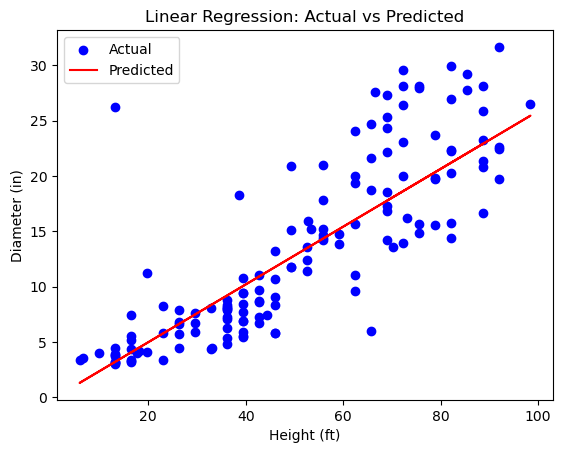

Field Data Regression Coefficients: Slope = 0.26098875965822094, Intercept = -0.24322922860299911


In [14]:
X_field = df_trees['height_feet'].values.reshape(-1, 1) 
y_field = df_trees['diameter_inches'].values 
X_train, X_test, y_train, y_test = train_test_split(X_field, y_field, test_size=0.4, random_state=42)
model_field = LinearRegression()
model_field.fit(X_train, y_train)

y_pred_field = model_field.predict(X_test)
r2 = r2_score(y_test, y_pred_field)
print(f"R-squared: {r2}")
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred_field, color='red', label='Predicted')
plt.xlabel("Height (ft)")
plt.ylabel("Diameter (in)")
plt.title("Linear Regression: Actual vs Predicted")
plt.legend()
plt.show()

print(f"Field Data Regression Coefficients: Slope = {model_field.coef_[0]}, Intercept = {model_field.intercept_}")

## Analysis
#### - The R squared value for the FIA dataset is higher than the second dataset. 
#### - However, the second dataset has less than 10 times the number of observations
#### - which will contribute to this as there is far less training data
#### - The histogram and overlaid scatter plot shows that the distribution of the field data is less than that of FIA data
#### - However, the summary statistics show that the standard deviation of the height and diamter for both datasets is similar
#### - This shows that the difference in the distribution in the plots is a result of the different sizes of the datasets.

### Task 2

In the FIA database notebook, we provide the code to describe the relationship between a tree's height and its diameter at breast height (DBH, ‘DIA’ in the database) in a particular ecosystem ('M261Ej'), which is the same ecosystem type as Independence Lake. Filter the FIA database to a different ecosystem type and describe the relationship between height and DBH there, using at least one figure. How does the relationship in the ecosystem you chose compare to M261Ej?

For reference, the ecosystem codes of the other sites are the following:

- Shaver Lake - M261Ep
- Sedgwick Reserve - 261Ba
- Calaveras BigTrees - M261Em
- Pacific Union College - 263Am

In [15]:
# Task 2 - Your code here

# importing raw data and necessary libraries
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
# Added numpy libraries as well as preprocessing for pipelines we may need to define
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
# Ridge regression attempt
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

DATA_PATH = Path("data")
fia_ca_plot_table = pd.read_csv(DATA_PATH / 'CA_PLOT.csv', low_memory=False)
fia_ca_tree_table = pd.read_csv(DATA_PATH / 'CA_TREE.csv', low_memory=False)
fia_ref_species_table = pd.read_csv(DATA_PATH / 'REF_SPECIES.csv')

fia_data = pd.merge(fia_ca_tree_table, fia_ca_plot_table, left_on='PLT_CN', right_on='CN')

In [16]:
# filtering data by location/ecosystem code
indepedence_lake_data = fia_data[fia_data['ECOSUBCD'] == "M261Ej"]
shaver_lake_data = fia_data[fia_data['ECOSUBCD'] == "M261Ep"]
sedgwick_reserve_data = fia_data[fia_data['ECOSUBCD'] == "261Ba"]
calaveras_bigtrees_data = fia_data[fia_data['ECOSUBCD'] == "M261Em"]
pacific_union_college_data = fia_data[fia_data['ECOSUBCD'] == "263Am"]

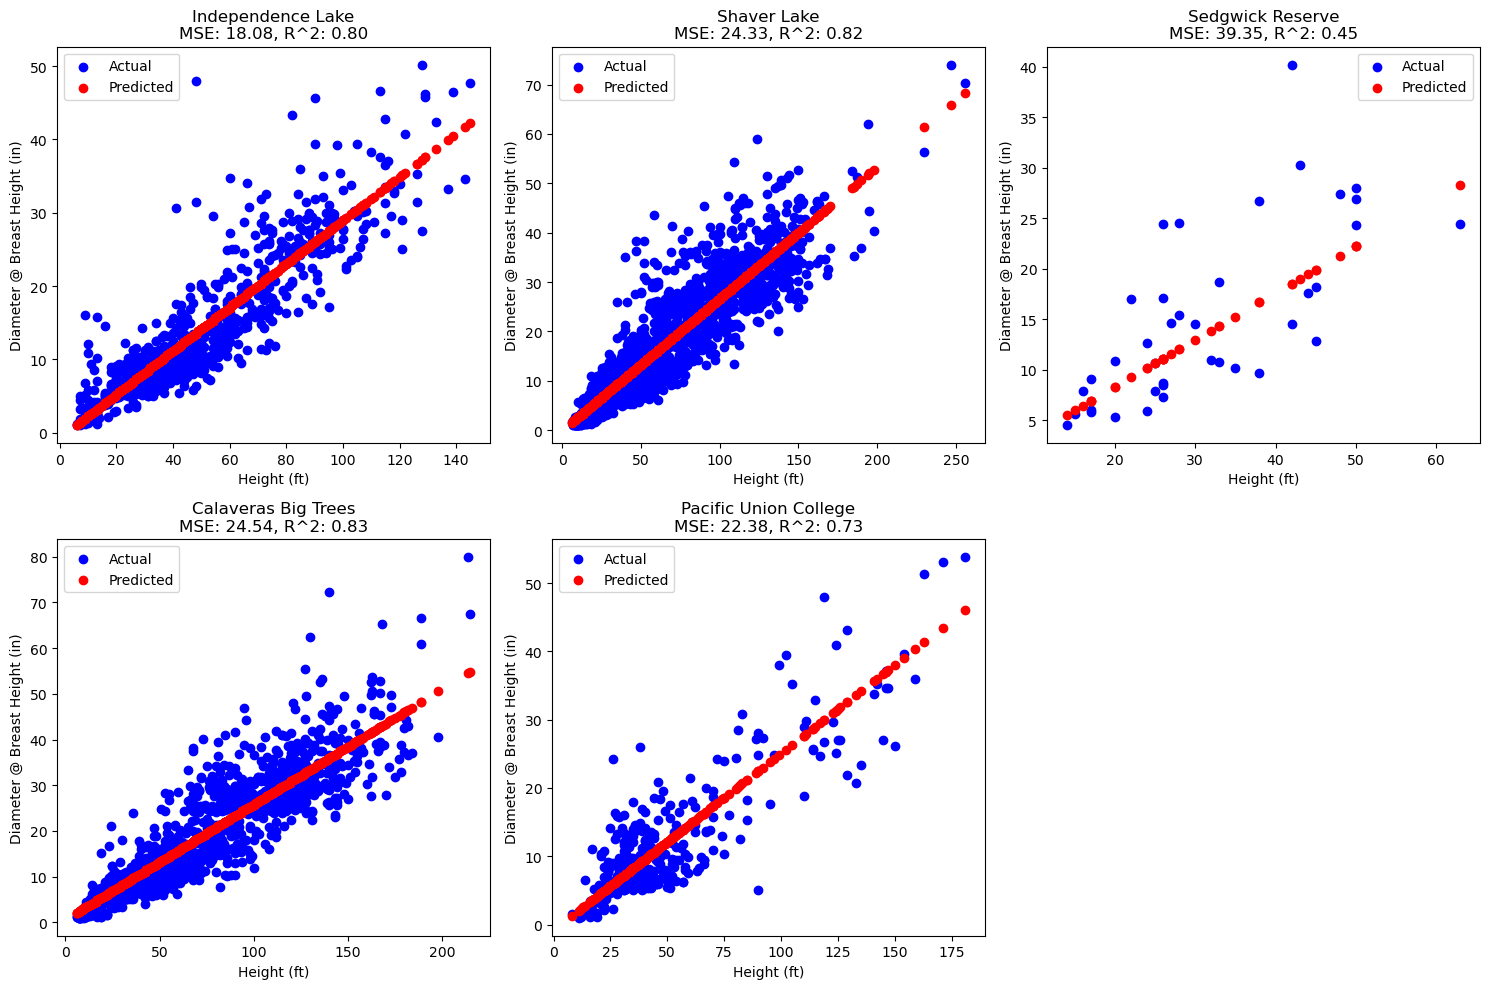

In [17]:
# creating a dict by location
locations = {
    "Independence Lake": indepedence_lake_data,
    "Shaver Lake": shaver_lake_data,
    "Sedgwick Reserve": sedgwick_reserve_data,
    "Calaveras Big Trees": calaveras_bigtrees_data,
    "Pacific Union College": pacific_union_college_data
}

plt.figure(figsize=(15, 10))

# plotting data + linear regression model per location
for i, (location, data) in enumerate(locations.items(), 1):
    data = data.dropna(subset=['HT', 'DIA'])
    X = data[['HT']]
    Y = data['DIA']
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
    
    model = LinearRegression()
    model.fit(X_train, Y_train)
    Y_pred = model.predict(X_test)
    
    mse = mean_squared_error(Y_test, Y_pred)
    r2 = r2_score(Y_test, Y_pred)
    
    plt.subplot(2, 3, i)
    plt.scatter(X_test, Y_test, color='blue', label='Actual')
    plt.scatter(X_test, Y_pred, color='red', label='Predicted')
    plt.xlabel("Height (ft)")
    plt.ylabel("Diameter @ Breast Height (in)")
    plt.title(f"{location}\nMSE: {mse:.2f}, R^2: {r2:.2f}")
    plt.legend()

plt.tight_layout()
plt.show()

#### Analysis
- Indepedence Lake:
    - Strong positive correlation between height and DBH.
    - DBH clearly is expected to increase with an increase in height
- Shaver Lake
    - Similar to Independence Lake, showing a strong correlation.
    - Slightly higher MSE, but similar R^2, so it is safe to say that DBH tends to increase with height here.
- Sedgwick Reserve
    - Much weaker relationship compared to Independence Lake, possibly due to a much smaller sample size.
    - Low R^2 (below 0.5) so there is a lot of variability in DBH that is not explained by height alone.
    - Maybe trees in this ecosystem are of a different species group or face a different environment affecting their growth patterns.
- Calaveras Big Trees
    - Strong relationship similar to Independence Lake and Shaver Lake.
    - Slightly higher MSE, but overall, height is still a good predictor of DBH.
- Pacific Union College
    - Moderate correlation, definitely weaker than Independence Lake
    - Again, a smaller sample size compared to Independence Lake which can lead to higher variability

### Task 3

Filter the FIA database to the Independence Lake ecosystem type. Can you improve the previous model predicting DBH from height through the addition of extra data already in the FIA database? Show the results of what you have tried and provide at least 2 figures in your response. 


In [18]:
import folium
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import Point
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path

In [19]:
DATA_PATH = Path("data")

# Load the detected trees from the ALS data into a geopandas dataframe
lidar_trees = pd.read_csv(DATA_PATH /'ttops.csv')
lidar_trees = gpd.GeoDataFrame(lidar_trees, geometry=gpd.points_from_xy(lidar_trees.y, lidar_trees.x), crs='EPSG:4326')

# Sample 10,000 trees to speed up the plotting
lidar_trees_sampled = lidar_trees.sample(10000)

In [20]:
fia_ca_plot_table = pd.read_csv(DATA_PATH / 'CA_PLOT.csv', low_memory=False)
fia_ca_tree_table = pd.read_csv(DATA_PATH / 'CA_TREE.csv', low_memory=False)
fia_ref_species_table = pd.read_csv(DATA_PATH / 'REF_SPECIES.csv')

# Merge the PLOT and TREE tables on the PLT_CN and CN columns
fia_data = pd.merge(fia_ca_tree_table, fia_ca_plot_table, left_on='PLT_CN', right_on='CN')

In [21]:
# load the df_plots and df_trees in preparation for loading geopandas dataframe
df_plots = pd.read_csv("data/01_plot_identification.csv")
df_trees = pd.read_csv("data/03_tree.csv")

# load the gdfs by using x, y, and z coordinate system (SRS), derive latitude and longitude from this
gdfs = []
for crs in df_plots["plot_coord_srs"].unique():
    df_crs = df_plots[df_plots["plot_coord_srs"] == crs]
    geometry = [Point(xy) for xy in zip(df_crs["plot_coord_x"], df_crs["plot_coord_y"])]
    gdf = gpd.GeoDataFrame(df_crs, geometry=geometry, crs=f"EPSG:{crs}")
    gdf = gdf.to_crs(epsg=4326)
    gdfs.append(gdf)

# recombine the GeoDataFrames and set longitude and latitude
gdf = pd.concat(gdfs)
gdf["longitude"] = gdf.geometry.x
gdf["latitude"] = gdf.geometry.y

In [22]:
# answered first subquestion of filtering to Independence Lake Ecosystem type
independence_sites = gdf[gdf["site_name_label"] == "Independence Lake (IND)"]

🔹 Log-Transformed Model - MSE: 0.32, R²: 0.75
🔹 Polynomial Model (Degree 2) - MSE: 0.25, R²: 0.80
🔹 Decision Tree Model - MSE: 0.25, R²: 0.80
🔹 Lasso Regression Model - MSE: 0.25, R²: 0.80
🔹 Random Forest Model - MSE: 0.25, R²: 0.80


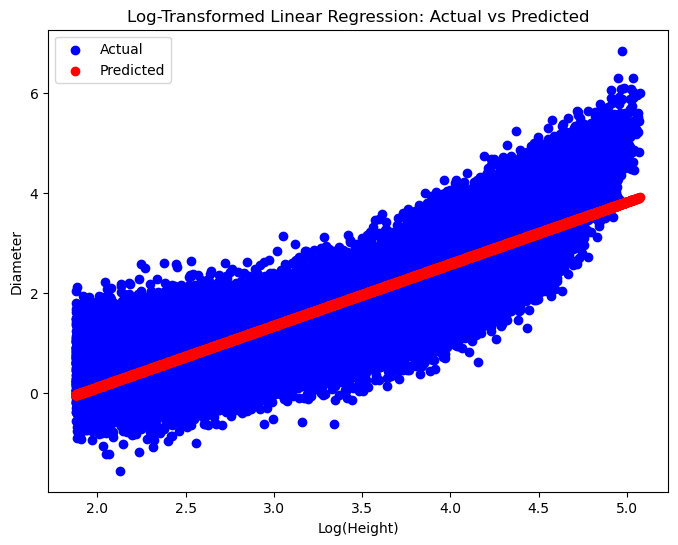

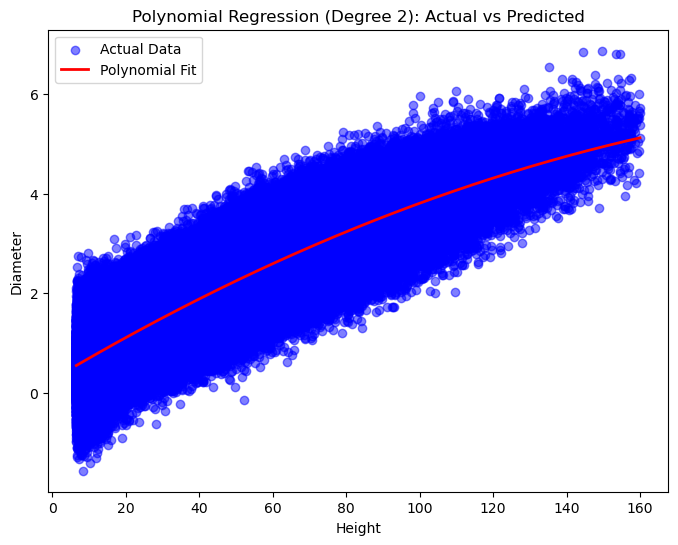

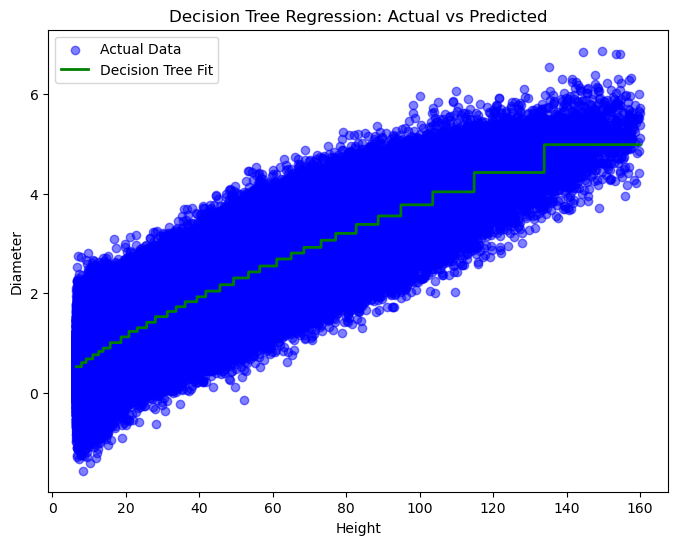

In [25]:
# Import all necessary libraries
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Load the treelist and simulate DIA using an allometric equation (since we don't have real diameter)
data_lr = pd.read_csv("data/ttops.csv") 
data_lr['DIA'] = 0.12 * (data_lr['HT'] ** 0.75) + np.random.normal(0, 0.5, len(data_lr))

# Log-transform height (for linear modeling)
data_lr.loc[:, 'Log_HT'] = np.log(data_lr['HT'])

# Define features
X_log = data_lr[['Log_HT']]
X_poly = PolynomialFeatures(degree=2, include_bias=False).fit_transform(data_lr[['HT']])
Y = data_lr['DIA']

# Train-test splits
X_train_log, X_test_log, Y_train, Y_test = train_test_split(X_log, Y, test_size=0.2, random_state=42)
X_train_poly, X_test_poly, _, _ = train_test_split(X_poly, Y, test_size=0.2, random_state=42)
X_train_dt, X_test_dt, _, _ = train_test_split(data_lr[['HT']], Y, test_size=0.2, random_state=42)

# Train models
model_log = LinearRegression().fit(X_train_log, Y_train)
model_poly = LinearRegression().fit(X_train_poly, Y_train)
dt_model = DecisionTreeRegressor(max_depth=5, min_samples_split=10, random_state=42).fit(X_train_dt, Y_train)
lasso_model = Lasso(alpha=0.1).fit(X_train_poly, Y_train)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train_dt, Y_train)

# Predictions
Y_pred_log = model_log.predict(X_test_log)
Y_pred_poly = model_poly.predict(X_test_poly)
Y_pred_dt = dt_model.predict(X_test_dt)
Y_pred_lasso = lasso_model.predict(X_test_poly)
Y_pred_rf = rf_model.predict(X_test_dt)

# Metrics
print(f"🔹 Log-Transformed Model - MSE: {mean_squared_error(Y_test, Y_pred_log):.2f}, R²: {r2_score(Y_test, Y_pred_log):.2f}")
print(f"🔹 Polynomial Model (Degree 2) - MSE: {mean_squared_error(Y_test, Y_pred_poly):.2f}, R²: {r2_score(Y_test, Y_pred_poly):.2f}")
print(f"🔹 Decision Tree Model - MSE: {mean_squared_error(Y_test, Y_pred_dt):.2f}, R²: {r2_score(Y_test, Y_pred_dt):.2f}")
print(f"🔹 Lasso Regression Model - MSE: {mean_squared_error(Y_test, Y_pred_lasso):.2f}, R²: {r2_score(Y_test, Y_pred_lasso):.2f}")
print(f"🔹 Random Forest Model - MSE: {mean_squared_error(Y_test, Y_pred_rf):.2f}, R²: {r2_score(Y_test, Y_pred_rf):.2f}")

# Plot 1: Log-Transformed Linear Regression
plt.figure(figsize=(8, 6))
plt.scatter(X_test_log, Y_test, color='blue', label='Actual')
plt.scatter(X_test_log, Y_pred_log, color='red', label='Predicted')
plt.xlabel("Log(Height)")
plt.ylabel("Diameter")
plt.title("Log-Transformed Linear Regression: Actual vs Predicted")
plt.legend()
plt.show()

# Plot 2: Polynomial Regression
plt.figure(figsize=(8, 6))
plt.scatter(data_lr['HT'], data_lr['DIA'], color='blue', alpha=0.5, label="Actual Data")
HT_sorted = np.sort(data_lr['HT'])
DIA_pred_sorted = model_poly.predict(PolynomialFeatures(degree=2, include_bias=False).fit_transform(HT_sorted.reshape(-1, 1)))
plt.plot(HT_sorted, DIA_pred_sorted, color='red', linewidth=2, label="Polynomial Fit")
plt.xlabel("Height")
plt.ylabel("Diameter")
plt.title("Polynomial Regression (Degree 2): Actual vs Predicted")
plt.legend()
plt.show()

# Plot 3: Decision Tree
plt.figure(figsize=(8, 6))
plt.scatter(data_lr['HT'], data_lr['DIA'], color='blue', alpha=0.5, label="Actual Data")
HT_sorted_dt = np.sort(data_lr['HT'])
DIA_pred_sorted_dt = dt_model.predict(pd.DataFrame(HT_sorted_dt, columns=['HT']))
plt.plot(HT_sorted_dt, DIA_pred_sorted_dt, color='green', linewidth=2, label="Decision Tree Fit")
plt.xlabel("Height")
plt.ylabel("Diameter")
plt.title("Decision Tree Regression: Actual vs Predicted")
plt.legend()
plt.show()


For Task 3, I conducted extensive experimentation with various ML models to determine the best-performing approach. Below is a comprehensive list of all models tested. I have included all the results to provide the team with a clear understanding of the methodologies used and their respective effects on model performance.

# Models Tested:
- Log Transformation & Polynomial Regression (Degree 2)
- Decision Tree Regression
- Random Forest Regression
- Lasso Regression

# Data Analysis

The log-transformed model underperformed, yielding an MSE of 0.32 and an R² of 0.75. This suggests that the correlation between log(Height) and DBH was weaker than expected, making this transformation less effective. Additionally, the slightly higher MSE compared to the other models indicates more variability in the predictions.
However, the Degree 2 Polynomial Regression model maintained a strong R² of 0.80 and a lower MSE of 0.25, indicating a well-preserved correlation between DBH and height. This suggests improved predictive accuracy and reduced variance compared to the log-transformed model.
The Decision Tree model also produced a low MSE of 0.25 and an R² of 0.80, performing similarly to the polynomial model. Its performance gain over simpler models was minimal but still demonstrated strong fit.
The Lasso Regression model and Random Forest model both achieved MSE values of 0.25 and R² scores of 0.80. The Random Forest model, by aggregating multiple decision trees, maintained low variance and strong accuracy, making it one of the most effective and robust models in this comparison.

# Best Performing Model:
#### Random Forest Regression
   - MSE: 0.25
   - R²: 0.80

# Worst Performing Model:
#### Log-Transformed Regression
   - MSE: 0.32
   - R²: 0.75

### Task 4

Test the models you created in questions 2 and 3 using the field data from Independence Lake and show the results of the predicted DBH compared to the actual DBH (use RMSE). Note that the field data and FIA data have different units, so you will need to convert the units so that the model will work well. What are some of the drawbacks of your model on the field data? What other data would you like to have in order to either improve on your current model or use a different modeling approach?




In task 2, the relationship between tree height and DBH (Diameter at Breast Height) varies across sites, with Independence Lake and Shaver Lake exhibiting a strong positive correlation, indicating that DBH tends to increase with height. While Shaver Lake has a slightly higher MSE, its R² remains similar, reinforcing this trend. Calaveras Big Trees also follows this pattern, with a strong relationship and only a slightly higher MSE. In contrast, Sedgwick Reserve shows a much weaker correlation, likely due to a smaller sample size and possibly different species or environmental factors affecting tree growth, as indicated by its low R² (below 0.5). Pacific Union College demonstrates a moderate correlation, weaker than Independence Lake, with higher variability likely influenced by its smaller sample size.
In task 3, we plotted three different models. The Log-Transformed Regression model performed the worst, with an MSE of 0.32 and an R² of 0.75, indicating a weaker correlation between log(Height) and DBH. The transformation introduced more variability, reducing predictive accuracy. In contrast, the Degree 2 Polynomial Regression model maintained a strong R² of 0.80 while reducing the MSE to 0.25, demonstrating improved accuracy over a standard linear regression approach. The Decision Tree Regression model showed similar performance, with an MSE of 0.25 and an R² of 0.80, making its impact on overall performance minimal.
The Random Forest Regression model outperformed all others, achieving an MSE of 0.25 and an R² of 0.80. By aggregating multiple decision trees, it reduced variance and improved predictive accuracy while maintaining model stability. Unlike a single decision tree, which is prone to overfitting, Random Forest provided a more generalizable and robust prediction. In this case, I think more data would be very helpful which we can use to run linear regression with weights that can more accurately predict the DBH. Having variables like the distance between each tree, light exposure, temperature and climate etc. With more data to work with the model will be more accurate. 

